# Libreries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Splits

In [2]:
X = pd.read_csv('/content/X_features.csv')
y = pd.read_csv('/content/y_target.csv')

print(X.shape, y.shape)

(115491, 18) (115491, 1)


# Función que valida NaN

In [3]:
def validar_X_y(X, y, target_name="is_profitable"):
    """
    Valida y sincroniza X e y antes de modelar.

    Parámetros:
    -----------
    X : pd.DataFrame
        Dataset de características.
    y : pd.Series o pd.DataFrame
        Target a predecir.
    target_name : str
        Nombre de la columna de target si es un DataFrame.

    Retorna:
    --------
    X_val : pd.DataFrame
        Dataset de características limpio.
    y_val : pd.Series
        Target limpio.
    """

    # Si y es un DataFrame, convertir a Series
    if isinstance(y, pd.DataFrame):
        if target_name in y.columns:
            y = y[target_name]
        else:
            raise ValueError(f"Target '{target_name}' no encontrado en DataFrame y.")

    # Concatenar X e y
    df_temp = pd.concat([X, y], axis=1)

    # Guardar shape original
    shape_original = df_temp.shape

    # Dropear filas con NaNs
    df_temp = df_temp.dropna()

    # Chequear cambios
    shape_final = df_temp.shape
    if shape_original != shape_final:
        print(f"Se eliminaron {shape_original[0] - shape_final[0]} filas por NaNs.")
    else:
        print("No se encontraron NaNs. X e y están limpios y sincronizados.")

    # Separar de nuevo
    X_val = df_temp.drop(y.name, axis=1)
    y_val = df_temp[y.name]

    # Validar shapes
    assert X_val.shape[0] == y_val.shape[0], "Error: X e y aún no tienen el mismo número de filas."

    return X_val, y_val

In [4]:
# Llamada a la función para validar y limpiar
X, y = validar_X_y(X, y)

Se eliminaron 1 filas por NaNs.


# XG Boost

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Tamaño de entrenamiento:', X_train.shape)
print('Tamaño de test:', X_test.shape)

Tamaño de entrenamiento: (92392, 18)
Tamaño de test: (23098, 18)


In [7]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:46:05] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [8]:
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [11]:
nuevo_threshold= 0.4
y_pred_threshold_xgb = (y_pred_proba_xgb >= nuevo_threshold).astype(int)

🔎 Resultados XGBoost (Threshold = 0.4)
Accuracy: 0.9987
Precision: 0.9787
Recall: 0.9918
F1 Score: 0.9852
ROC AUC Score: 1.0
\ Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     22123
         1.0       0.98      0.99      0.99       975

    accuracy                           1.00     23098
   macro avg       0.99      1.00      0.99     23098
weighted avg       1.00      1.00      1.00     23098



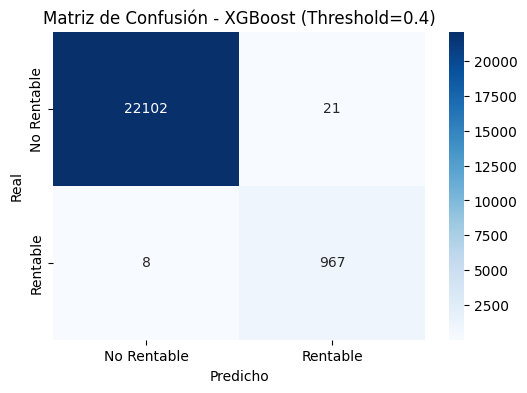

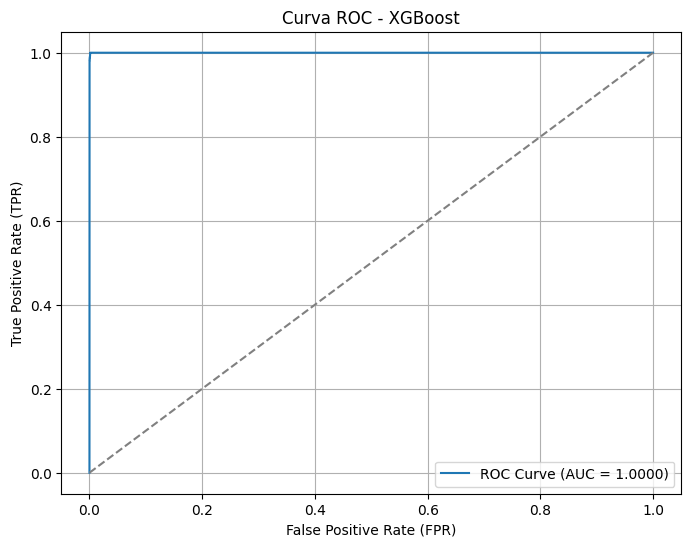

In [12]:
#  Calculamos métricas
print("🔎 Resultados XGBoost (Threshold = 0.4)")
print("Accuracy:", round(accuracy_score(y_test, y_pred_threshold_xgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_threshold_xgb), 4))
print("Recall:", round(recall_score(y_test, y_pred_threshold_xgb), 4))
print("F1 Score:", round(f1_score(y_test, y_pred_threshold_xgb), 4))
print("ROC AUC Score:", round(roc_auc_score(y_test, y_pred_proba_xgb), 4))

print("\ Classification Report:")
print(classification_report(y_test, y_pred_threshold_xgb))

# Matriz de Confusión
conf_matrix_xgb = confusion_matrix(y_test, y_pred_threshold_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap="Blues", xticklabels=['No Rentable', 'Rentable'], yticklabels=['No Rentable', 'Rentable'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión - XGBoost (Threshold=0.4)')
plt.show()

#  Curva ROC
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)
auc_score_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(fpr_xgb, tpr_xgb, label=f'ROC Curve (AUC = {auc_score_xgb:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Curva ROC - XGBoost')
plt.legend()
plt.grid()
plt.show()

#  Conclusiones - XGBoost Classifier

- XGBoost logró una performance excepcional en la predicción de rentabilidad:
  - Accuracy del 99.87%.
  - Precision de 97.87%.
  - Recall de 99.18%.
  - F1 Score de 98.52%.
  - Área bajo la curva ROC (AUC) perfecta de 1.0000.

- La matriz de confusión muestra una cantidad mínima de errores:
  - 21 falsos positivos.
  - 8 falsos negativos.

- Comparado con Random Forest:
  - XGBoost mostró un Recall ligeramente superior.
  - Random Forest mostró una precisión global ligeramente más alta.

 Ambos modelos son altamente efectivos para la clasificación de paquetes rentables en este proyecto.

---
